# Region boundaries and budgets on the ECCO LLC90 lat-lon-cap grid

This example applies `regionate` to the **ECCOv4r4 native lat-lon-cap (LLC90)** grid — a
genuinely *multi-tile* ocean grid whose 13 tiles are connected by an `xgcm`
`face_connections` topology (with rotated seams and an Arctic "cap"). It

1. traces the **Atlantic basin** into a single grid-conforming boundary spanning many tiles;
2. verifies that a traced boundary obeys the **discrete divergence theorem** (the property
   that makes region budgets consistent with boundary fluxes); and
3. builds a **latitude-circle** section across the basin (`curve="latitude circle"`).

The grid is loaded natively (MITgcm 'left'-staggered vorticity points), which `sectionate`
supports directly.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from load_example_ECCO_grid import load_ECCO_LLC90_grid, atlantic_basin_mask
from regionate import MaskRegions
import sectionate as sec

grid = load_ECCO_LLC90_grid()
grid

<xgcm.Grid>
X Axis (not periodic, boundary='fill'):
  * center   i --> left
  * left     i_g --> center
Y Axis (not periodic, boundary='fill'):
  * center   j --> left
  * left     j_g --> center

## The Atlantic basin mask

We use the published **Natural Earth ocean basins** via `regionmask` (the open Atlantic is
split into several named basins — North/South Atlantic, Sargasso Sea, Caribbean, etc. — so
we union the Atlantic-sector basins; see `ATLANTIC_BASINS`). Published basin polygons keep
the mask geographically correct: it follows the coastlines, fills the central Atlantic, and
excludes the Pacific.

In [2]:
atlantic = atlantic_basin_mask(grid)
lon, lat = grid._ds["geolon"], grid._ds["geolat"]
tiles_in_mask = sorted(set(np.where(atlantic.values.any(axis=(1, 2)))[0].tolist()))
print(f"Atlantic ocean cells: {int(atlantic.sum())}  spanning tiles: {tiles_in_mask}")

Atlantic ocean cells: 11284  spanning tiles: [0, 1, 2, 10, 11, 12]


## Trace the basin boundary

`MaskRegions` traces the mask. The basin perimeter is the largest loop; the smaller loops
are islands / interior coastline. The per-corner face index `f_c` spans every tile the
Atlantic touches — the boundary is stitched across the rotated tile seams and the cap.

In [3]:
regions = MaskRegions(atlantic, grid).region_dict
basin = max(regions.values(), key=lambda r: len(r.lons_c))
faces = np.asarray(basin.f_c)[:-1]   # f_c is a closed loop; align with the open lon/lat
print(f"boundary loops (basin + islands): {len(regions)}")
print(f"basin perimeter: {len(basin.lons_c)} corners, spanning tiles {sorted(set(faces.tolist()))}")

boundary loops (basin + islands): 18
basin perimeter: 926 corners, spanning tiles [0, 1, 2, 10, 11, 12]


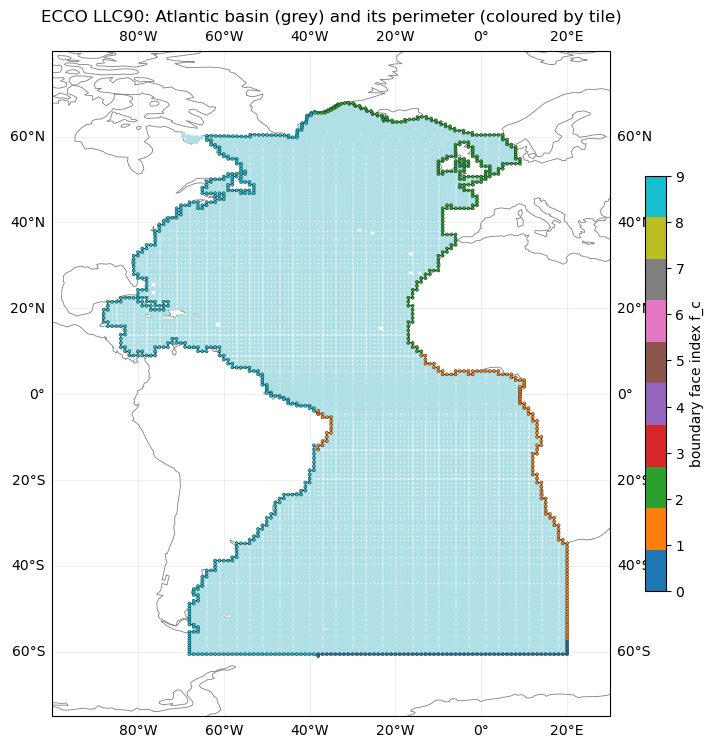

In [4]:
fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-100, 30, -75, 80], crs=ccrs.PlateCarree())
ax.coastlines(color="0.5", linewidth=0.6)
ax.gridlines(draw_labels=True, alpha=0.2)

# interior masked cells: one muted colour, larger filled dots
for t in tiles_in_mask:
    mt = atlantic.isel(tile=t).values
    ax.scatter(lon.isel(tile=t).values[mt], lat.isel(tile=t).values[mt],
               s=6, color="powderblue", zorder=2)
# boundary corner points: a different (categorical-by-face) colour map, smaller, thin black edges
ax.plot(basin.lons_c, basin.lats_c, "-", color="k", lw=0.5, zorder=4)
sc = ax.scatter(basin.lons_c, basin.lats_c, c=faces, cmap="tab10", vmin=0, vmax=9,
                s=5, zorder=5, edgecolor="k", linewidth=0.25)
plt.colorbar(sc, ax=ax, label="boundary face index f_c", shrink=0.6)
ax.set_title("ECCO LLC90: Atlantic basin (grey) and its perimeter (coloured by tile)")
plt.show()

## Budget consistency: the discrete divergence theorem

The point of a grid-consistent boundary is that **region budgets balance the fluxes through
the boundary**: for any quantity whose transports live on the staggered velocity faces, the
net flux through the region boundary equals the flux convergence summed over the region's
cells. We check this directly with a synthetic transport field on a North-Atlantic region
that crosses the tile-1/tile-2 seam.

In [5]:
depth = grid._ds["Depth"]
region_mask = ((depth > 0) & (lon > -30) & (lon < 20) & (lat > -5) & (lat < 25)).compute()

# synthetic mass transports on the staggered velocity faces (U on i_g, V on j_g)
nf, ny, nx = grid._ds.sizes["tile"], grid._ds.sizes["j"], grid._ds.sizes["i"]
g = np.arange(nf * ny * nx, dtype=float).reshape(nf, ny, nx)
umo = (np.sin(g * 0.013) + 0.3).reshape(nf, ny, nx)
vmo = (np.cos(g * 0.017) - 0.2).reshape(nf, ny, nx)
grid._ds["umo"] = (("tile", "j", "i_g"), umo)
grid._ds["vmo"] = (("tile", "j_g", "i"), vmo)

# (a) flux convergence summed over the masked cells (xgcm handles the tile topology)
convergence = float((-(grid.diff(grid._ds["umo"], "X") + grid.diff(grid._ds["vmo"], "Y"))
                     ).where(region_mask, 0.).sum())

# (b) net flux through every traced boundary face (sum over the region's loops)
boundary_flux = 0.0
for r in MaskRegions(region_mask, grid).region_dict.values():
    uv = sec.uvindices_from_qindices(grid, r.i_c, r.j_c, f_c=r.f_c)
    for k in range(len(uv["var"])):
        if uv["var"][k] == "0":
            continue
        f, i, j = int(uv["face"][k]), int(uv["i"][k]), int(uv["j"][k])
        t = umo[f, j, i] if uv["var"][k] == "U" else vmo[f, j, i]
        boundary_flux += int(uv["Lsign"][k]) * t

print(f"flux convergence over region cells = {convergence:.10f}")
print(f"net flux through boundary faces    = {boundary_flux:.10f}")
print(f"divergence theorem residual        = {convergence - boundary_flux:.2e}")

flux convergence over region cells = 16.1644033653
net flux through boundary faces    = 16.1644033653
divergence theorem residual        = -1.78e-14


The residual is at the level of floating-point round-off: regionate's boundary faces are
*exactly* the faces that separate in-mask from out-of-mask cells, so the discrete divergence
theorem holds.

(With real ECCO velocity output one would use `sectionate.convergent_transport`, which
performs the same boundary integral while correctly handling the rotated seams and the cap —
where computing a cell-centred divergence from `u`/`v` directly is subtle because the LLC
seam rotates `u` into `v`. The check above uses a region with a non-rotated seam so the
cell-centred convergence is itself unambiguous.)

## A latitude-circle section across the basin

Besides masks, regionate/sectionate can trace **sections** between waypoints. With
`curve="latitude circle"` the section follows a parallel of latitude rather than a great
circle — exactly what you want for a meridional-overturning transect. Here is a ~26°N
section across the North Atlantic (it crosses the rotated tile-2/tile-10 seam).

latitude-circle section: 67 corners, tiles [2, 10], lat in [25.22, 26.13]
great-circle section bows north: lat in [26.13, 30.55]


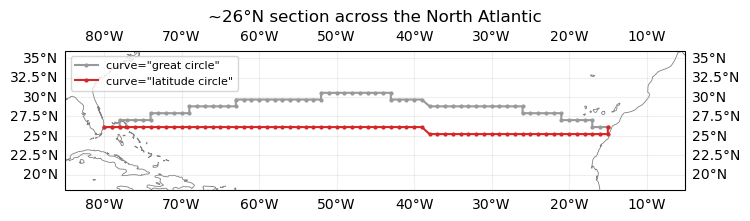

In [6]:
i_c, j_c, f_c, slon, slat = sec.grid_section(grid, [-80., -15.], [26., 26.],
                                             curve="latitude circle")
gc = sec.grid_section(grid, [-80., -15.], [26., 26.], curve="great circle")
print(f"latitude-circle section: {len(i_c)} corners, tiles {sorted(set(f_c.tolist()))}, "
      f"lat in [{slat.min():.2f}, {slat.max():.2f}]")
print(f"great-circle section bows north: lat in [{gc[4].min():.2f}, {gc[4].max():.2f}]")

fig = plt.figure(figsize=(8, 4))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-85, -5, 18, 36], crs=ccrs.PlateCarree())
ax.coastlines(color="0.5", linewidth=0.6); ax.gridlines(draw_labels=True, alpha=0.2)
ax.plot(gc[3], gc[4], "-o", ms=2, color="0.6", label='curve="great circle"')
ax.plot(slon, slat, "-o", ms=2, color="C3", label='curve="latitude circle"')
ax.legend(loc="upper left", fontsize=8)
ax.set_title("~26°N section across the North Atlantic")
plt.show()

## Notes

- regionate traces the boundary face-by-face with `contourpy`, removes internal tile-seam
  faces (in-mask on both sides), and stitches the remaining open arcs across seams using the
  grid topology (cell adjacency) — no reliance on coordinate coincidence, so rotated/reversed
  seams and the cap are handled uniformly.
- The native 'left' MITgcm/ECCO staggering is consumed directly via `sectionate.gridutils`
  (`corner_position`/`corner_offset`); the same code path handles symmetric ('outer') and
  'right' grids.